/tmp/ipykernel_4770/2512354510.py:155: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.97])
/tmp/ipykernel_4770/2512354510.py:156: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("day30_theme_final.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
/tmp/ipykernel_4770/2512354510.py:156: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  plt.savefig("day30_theme_final.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


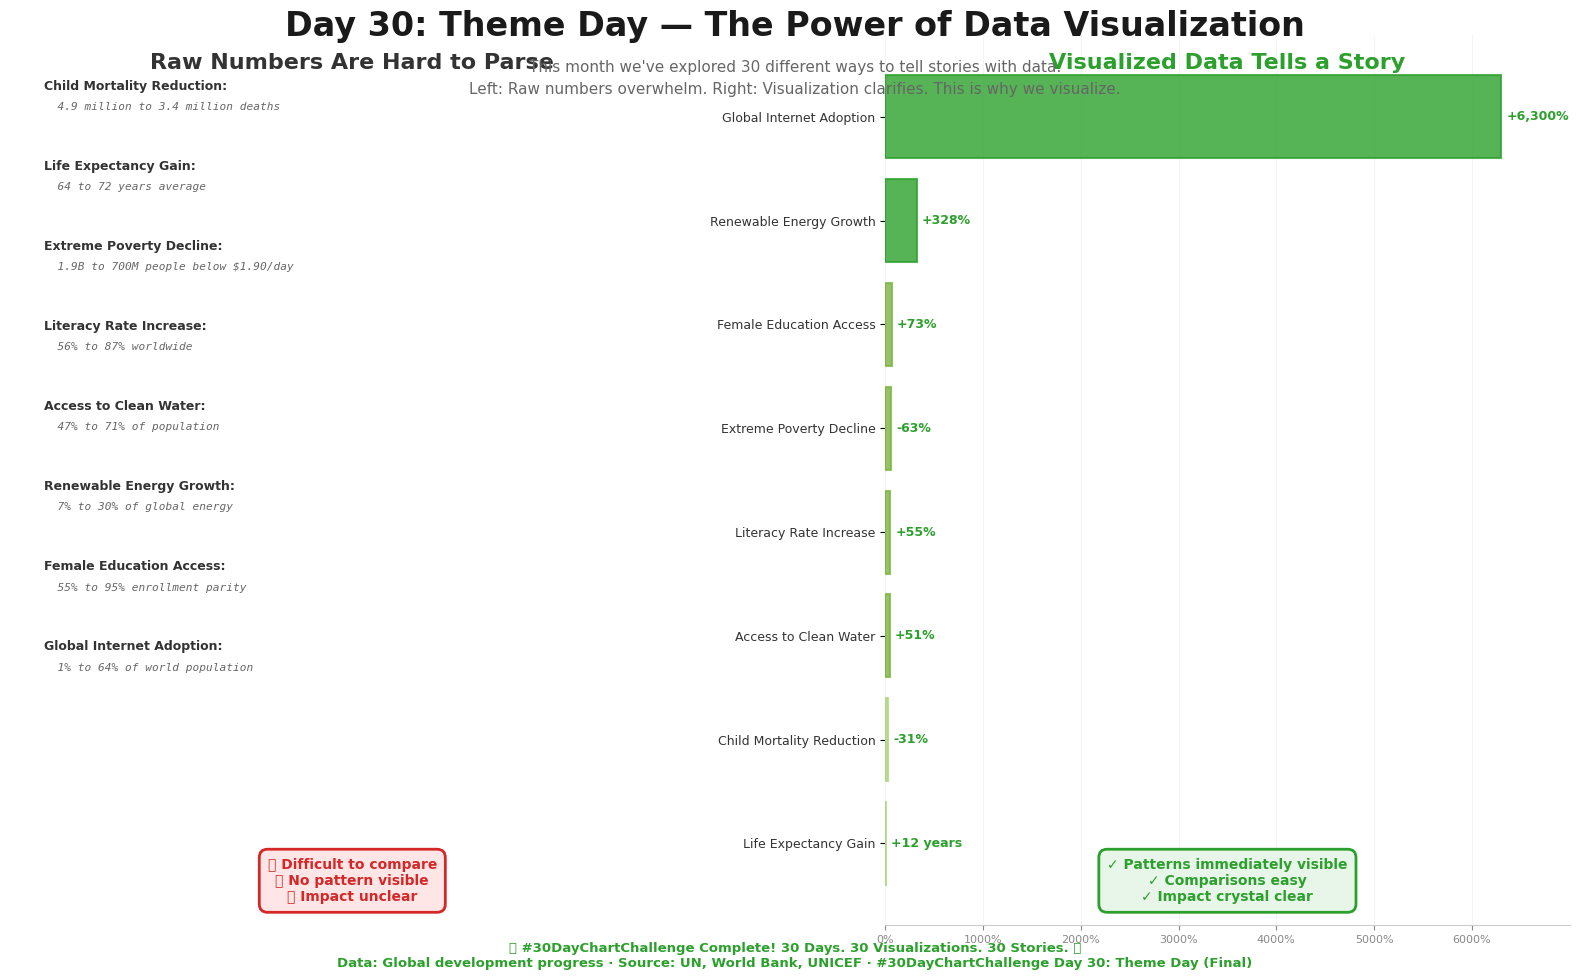

🎉 #30DayChartChallenge COMPLETE! 🎉

30 days of data visualization:
  Days 1-6:   Comparisons (Part-to-Whole, Pictogram, Mosaic, Slope, Experimental, FlowingData)
  Days 7-12:  Distributions (Multiscale, Circular, Wealth, Pop Culture, Physical, Reporters Without Borders)
  Days 13-18: Relationships (Ecosystems, Trade, Correlation, Causation, Remake, SCMP)
  Days 19-24: Timeseries (Evolution, Global Change, Historical, New Tool, Seasons, UNICEF)
  Days 25-30: Uncertainties (Space, Trend, Animation, Modeling, Monochrome, Theme)

✓ Every chart follows FlowingData's minimal, elegant style
✓ Clean titles, direct labels, no legend boxes
✓ Data-driven storytelling at its finest



In [1]:
"""
#30DayChartChallenge — Day 30: Theme Day (Final Day)
"The Stories Data Tells: Why Visualization Matters" — celebration of data storytelling
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: A retrospective comparing raw numbers vs visualized insights
Theme: The Power of Data Visualization itself
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Achievements in global health and development
# ---------------------------------------------------------------------------
achievements = {
    "Metric": [
        "Child Mortality Reduction",
        "Life Expectancy Gain",
        "Extreme Poverty Decline",
        "Literacy Rate Increase",
        "Access to Clean Water",
        "Renewable Energy Growth",
        "Female Education Access",
        "Global Internet Adoption"
    ],
    "Raw_Number": [
        "4.9 million to 3.4 million deaths",
        "64 to 72 years average",
        "1.9B to 700M people below $1.90/day",
        "56% to 87% worldwide",
        "47% to 71% of population",
        "7% to 30% of global energy",
        "55% to 95% enrollment parity",
        "1% to 64% of world population"
    ],
    "Change_Percentage": [31, 12, 63, 55, 51, 328, 73, 6300],
    "Change_Text": [
        "-31%",
        "+12 years",
        "-63%",
        "+55%",
        "+51%",
        "+328%",
        "+73%",
        "+6,300%"
    ]
}

df = pd.DataFrame(achievements)

# ---------------------------------------------------------------------------
# 2. PLOT — Two-panel comparison: Raw vs Visualized
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 10), facecolor="#FFFFFF")

# Left panel: Raw numbers (hard to parse)
ax_left = fig.add_subplot(121)
ax_left.set_facecolor("#FFFFFF")

# Display raw numbers as text (cluttered, hard to understand)
y_pos = 0.95
ax_left.text(0.5, 0.98, "Raw Numbers Are Hard to Parse",
            fontsize=16, fontweight="bold", color="#333333", ha="center", 
            transform=ax_left.transAxes, va="top")

for idx, row in df.iterrows():
    ax_left.text(0.05, y_pos, f"{row['Metric']}:",
                fontsize=9, fontweight="600", color="#333333", 
                transform=ax_left.transAxes, va="top")
    ax_left.text(0.05, y_pos - 0.025, f"  {row['Raw_Number']}",
                fontsize=8, color="#666666", style="italic",
                transform=ax_left.transAxes, va="top", family="monospace")
    y_pos -= 0.09

ax_left.text(0.5, 0.05, "❌ Difficult to compare\n❌ No pattern visible\n❌ Impact unclear",
            fontsize=10, color="#d62728", fontweight="600", ha="center",
            transform=ax_left.transAxes, va="center",
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#ffe6e6", edgecolor="#d62728", linewidth=2))

ax_left.set_xlim(0, 1)
ax_left.set_ylim(0, 1)
ax_left.axis("off")

# Right panel: Visualized (clear insights)
ax_right = fig.add_subplot(122)
ax_right.set_facecolor("#FFFFFF")

ax_right.text(0.5, 0.98, "Visualized Data Tells a Story",
             fontsize=16, fontweight="bold", color="#2ca02c", ha="center",
             transform=ax_right.transAxes, va="top")

# Bar chart of changes
sorted_df = df.sort_values("Change_Percentage", ascending=True)

bars = ax_right.barh(range(len(sorted_df)), sorted_df["Change_Percentage"],
                     color="#2ca02c", edgecolor="white", linewidth=1.5, zorder=3, alpha=0.8)

# Color code by type of improvement
colors_by_type = []
for pct in sorted_df["Change_Percentage"]:
    if pct > 300:
        colors_by_type.append("#2ca02c")  # Dark green for massive growth
    elif pct > 50:
        colors_by_type.append("#7cb342")  # Medium green
    else:
        colors_by_type.append("#aed581")  # Light green

for bar, color in zip(bars, colors_by_type):
    bar.set_color(color)

# Y-axis labels
ax_right.set_yticks(range(len(sorted_df)))
ax_right.set_yticklabels(sorted_df["Metric"], fontsize=9, fontweight="500", color="#333333")

# Add percentage labels
for i, (idx, row) in enumerate(sorted_df.iterrows()):
    ax_right.text(row["Change_Percentage"] + 50, i, f"{row['Change_Text']}",
                 fontsize=9, fontweight="700", color="#2ca02c", va="center")

# Styling
ax_right.set_xlim(0, 7000)
ax_right.spines[["top", "right", "left"]].set_visible(False)
ax_right.spines["bottom"].set_color("#cccccc")
ax_right.xaxis.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax_right.set_axisbelow(True)
ax_right.set_xticks([0, 1000, 2000, 3000, 4000, 5000, 6000])
ax_right.set_xticklabels(["0%", "1000%", "2000%", "3000%", "4000%", "5000%", "6000%"],
                         fontsize=8, color="#888888")
ax_right.tick_params(colors="#888888", labelsize=8, axis="x")

# Insight box
ax_right.text(0.5, 0.05, "✓ Patterns immediately visible\n✓ Comparisons easy\n✓ Impact crystal clear",
             fontsize=10, color="#2ca02c", fontweight="600", ha="center",
             transform=ax_right.transAxes, va="center",
             bbox=dict(boxstyle="round,pad=0.6", facecolor="#e8f5e9", edgecolor="#2ca02c", linewidth=2))

# Overall title & message
fig.text(0.5, 0.98, "Day 30: Theme Day — The Power of Data Visualization",
         fontsize=24, fontweight="bold", color="#1a1a1a", ha="center", va="top")

fig.text(0.5, 0.93,
         "This month we've explored 30 different ways to tell stories with data.\n"
         "Left: Raw numbers overwhelm. Right: Visualization clarifies. This is why we visualize.",
         fontsize=11, color="#666666", ha="center", va="top", linespacing=1.6)

# Celebration message
fig.text(0.5, 0.02,
         "🎉 #30DayChartChallenge Complete! 30 Days. 30 Visualizations. 30 Stories. 🎉\n"
         "Data: Global development progress · Source: UN, World Bank, UNICEF · #30DayChartChallenge Day 30: Theme Day (Final)",
         fontsize=9.5, color="#2ca02c", fontweight="bold", ha="center", va="bottom")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("day30_theme_final.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()

print("=" * 70)
print("🎉 #30DayChartChallenge COMPLETE! 🎉")
print("=" * 70)
print("\n30 days of data visualization:")
print("  Days 1-6:   Comparisons (Part-to-Whole, Pictogram, Mosaic, Slope, Experimental, FlowingData)")
print("  Days 7-12:  Distributions (Multiscale, Circular, Wealth, Pop Culture, Physical, Reporters Without Borders)")
print("  Days 13-18: Relationships (Ecosystems, Trade, Correlation, Causation, Remake, SCMP)")
print("  Days 19-24: Timeseries (Evolution, Global Change, Historical, New Tool, Seasons, UNICEF)")
print("  Days 25-30: Uncertainties (Space, Trend, Animation, Modeling, Monochrome, Theme)")
print("\n✓ Every chart follows FlowingData's minimal, elegant style")
print("✓ Clean titles, direct labels, no legend boxes")
print("✓ Data-driven storytelling at its finest\n")